## Linear Regression Example

You are a real estate agent and want to predict housing prices for regions in the USA. Create a model that allows to put in a few features of a house and returns back an estimate of what the house would sell for.

The data contains the following columns:

* **Avg. Income**: Avg. Income of residents of the city house is located in.
* **Avg. House Age**: Avg Age of Houses in the same city
* **Avg. Number of Rooms**: Avg Number of Rooms for Houses in same city.
* **Avg. Number of Bedrooms**: Avg Number of Bedrooms for Houses in same city.
* **Area Population**: Population of city house is located in.
* **Price**: Price that the house sold at.
* **Address**: Address for the house.

#### Import the data

In [1]:
!curl https://raw.githubusercontent.com/markumreed/colab_sklearn/main/housing.csv >> housing.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  709k  100  709k    0     0   871k      0 --:--:-- --:--:-- --:--:--  871k


In [2]:
!head housing.csv

Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
79545.45857431678,5.682861321615587,7.009188142792237,4.09,23086.800502686456,1059033.5578701235,"208 Michael Ferry Apt. 674
Laurabury, NE 37010-5101"
79248.64245482568,6.0028998082752425,6.730821019094919,3.09,40173.07217364482,1505890.91484695,"188 Johnson Views Suite 079
Lake Kathleen, CA 48958"
61287.067178656784,5.865889840310001,8.512727430375099,5.13,36882.15939970458,1058987.9878760849,"9127 Elizabeth Stravenue
Danieltown, WI 06482-3489"
63345.24004622798,7.1882360945186425,5.586728664827653,3.26,34310.24283090706,1260616.8066294468,"USS Barnett
FPO AP 44820"
59982.197225708034,5.040554523106283,7.839387785120487,4.23,26354.109472103148,630943.4893385402,"USNS Raymond


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
housing = pd.read_csv('housing.csv')

In [31]:
housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [32]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [33]:
housing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [34]:
housing.columns = [x.lower().replace('area', '').replace('.', '').replace('  ', '_').strip().replace(' ', '_') for x in housing.columns]

In [35]:
housing.columns

Index(['avg_income', 'avg_house_age', 'avg_number_of_rooms',
       'avg_number_of_bedrooms', 'population', 'price', 'address'],
      dtype='object')

### Exploratory Data Analysis

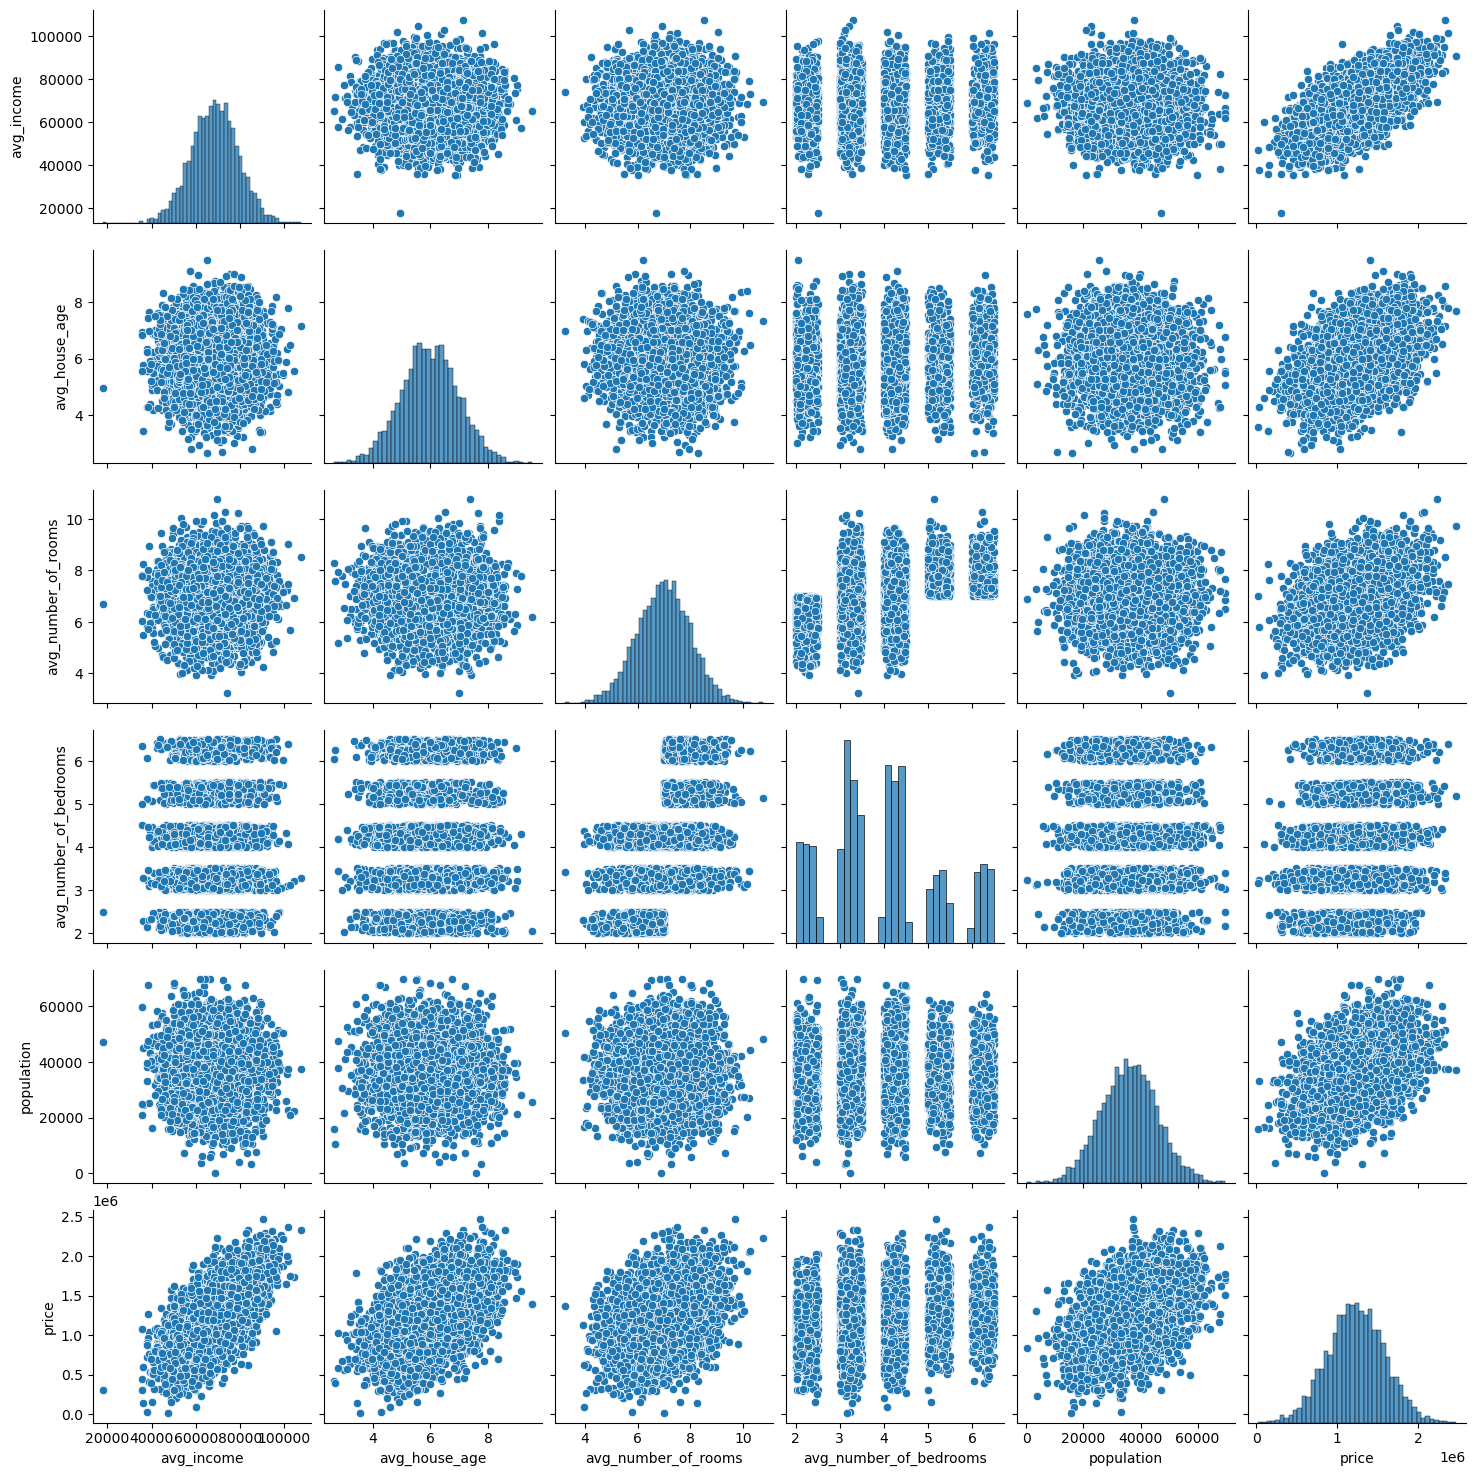

In [36]:
sns.pairplot(housing)

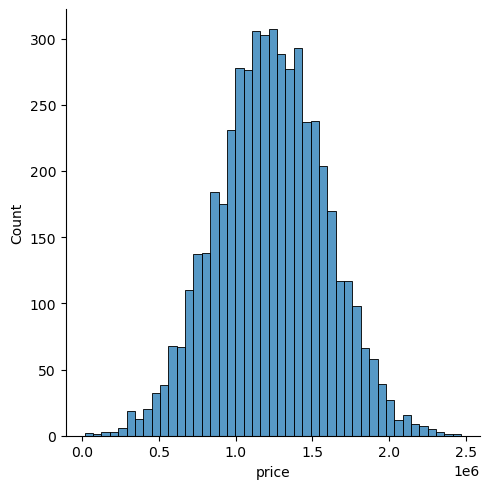

In [38]:
sns.displot(housing['price']);

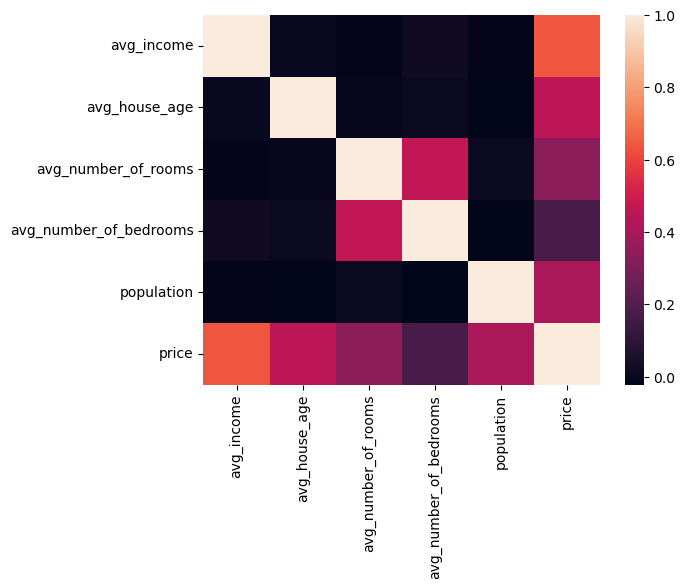

In [40]:
sns.heatmap(housing.corr(numeric_only=True));

### Linear Regression Model

* Split up our data into an X array that contains the features to train on, and a y array with the target variable, in this case the Price column.
* Remove the address column since it only has text info.

In [41]:
y = housing['price'].copy()
X = housing.drop(['price', 'address'], axis=1)

In [42]:
X

,avg_income,avg_house_age,avg_number_of_rooms,avg_number_of_bedrooms,population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [43]:
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: price, Length: 5000, dtype: float64

#### Train Test Split

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [46]:
X_train

,avg_income,avg_house_age,avg_number_of_rooms,avg_number_of_bedrooms,population
1522,67716.748222,6.431119,7.753989,5.28,40562.188948
835,78095.352630,6.837193,7.119862,3.00,32346.434992
358,55577.071754,6.533916,7.162536,3.47,19560.012414
138,63876.059910,7.080219,7.187433,3.37,38052.876443
299,52188.118727,5.636892,5.807401,4.03,42495.754677
...,...,...,...,...,...
4426,76223.561256,6.371627,5.342217,2.42,30165.337445
466,56685.014442,6.958045,7.502115,3.38,43322.166854
3092,66195.337714,6.507971,6.611861,3.14,37288.923574
3772,58694.515017,7.394768,9.269453,4.32,49960.977236


#### Create and Train Model

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
lm = LinearRegression()

In [49]:
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Model Evaluation

In [50]:
print(lm.intercept_)

-2638142.110430866


In [53]:
coef_df = pd.DataFrame(lm.coef_, index=X.columns, columns=['Coefficient'])
coef_df

,Coefficient
avg_income,21.589887
avg_house_age,166102.501246
avg_number_of_rooms,119895.936402
avg_number_of_bedrooms,1901.071012
population,15.231503


#### Interpreting the results

- Ceterus Paribus == "Holding all other features fixed" (CP)
- CP, a 1 unit increase in **avg_income** is associated with an **increase of $21.59**
  
- CP, a 1 unit increase in **avg_house_age** is associated with an **increase of $166102.5**
  
- CP, a 1 unit increase in **avg_number_of_rooms** is associated with an **increase of $119896**

- CP, a 1 unit increase in **avg_number_of_bedrooms** is associated with an **increase of $1901**

- CP, a 1 unit increase in **avg_number_of_rooms** is associated with an **increase of $15.23**

#### Model Predictions

In [54]:
predictions = lm.predict(X_test)

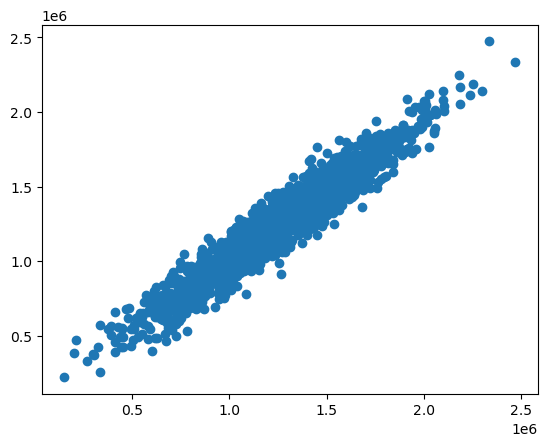

In [55]:
plt.scatter(y_test, predictions)

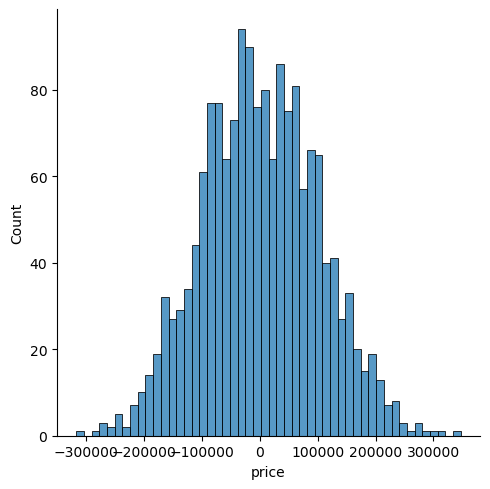

In [56]:
# Residual Plot
sns.displot((y_test - predictions), bins=50);

### Regression Evaluation Metrics

Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE): is the mean of the absolute value of the errors.

**Mean Squared Error** (MSE): is the mean of the squared errors.

**Root Mean Squared Error** (RMSE): is the square root of the mean of the squared errors.

Comparing these metrics:

* **MAE**: is the easiest to understand, because it's the average error.
* **MSE**: is more popular than MAE, because MSE "punishes" large errors, which tends to be useful in the real world.
* **RMSE**: is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [57]:
from sklearn import metrics

In [59]:
print("MAE", metrics.mean_absolute_error(y_test, predictions))
print("MSE", metrics.mean_squared_error(y_test, predictions))
print("RMSE", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE 80893.81190770479
MSE 10013679978.583364
RMSE 100068.376516177
